# Discrete State Space
## Numerical Experiments

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Literal, Optional, Tuple, Union

import math
import random

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64
torch.set_default_dtype(DTYPE)

def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)

set_seed(0)
print(device)

cuda


## 1. Two-State Two-Action Toy Problem [Meunier2026][17]
References:
[17] Haotian Gu, Xin Guo, Xiaoli Wei, and Renyuan Xu. Dynamic programming principles for mean-field controls with learning. Operations Research, 71(4):1040–1054, 2023
[24] Diederik P Kingma. Adam: A method for stochastic optimization. arXiv preprint arXiv:1412.6980, 2014.


The action space is $\mathcal A=\{\mathrm{ST}, \mathrm{MV}\}$ and the state space is $\mathcal X = \{0, 1\}$. The transition kernel is defined as follows: for $x\in\mathcal X, a\in\mathcal A, P(x'\mid x,a)=\lambda_x\mathbf 1_{a=\mathrm{MV}}$ if $x'\neq x$ and $P(x'\mid x,a)=1-\lambda_x\mathbf 1_{a=\mathrm{MV}}$ if $x'=x$, where $\lambda_0,\lambda_1\in(0,1)$ are fixed parameters. The running reward function is defined as
\begin{align}
    r(x,a,\mu)=r(x\mu)=\mathbf 1_{x=1} - \mu(1)^2-\lambda W_1(\mu,B),
\end{align}
where $W_1$ is the 1-Wasserstein distance, $\lambda>0$ is a fixed scalar parameter and B is a Bernoulli distribution with parameter $p$ such that $1-\lambda_0\leq p\leq \lambda_1$. The terminal reward function is $g(x,\mu)=r(x,\mu)$. Although the original problem in [17] is an infinite-horizon discounted problem, we consider here a finite-horizon version with time horizon $T$. In this setting, there exists an optimal stationary policy given by
\begin{align}
    \pi^\star(a\mid 0,\mu) &= \left(1-\frac{1-p}{\lambda_0} \right)\mathbf 1_{\{a=\mathrm{ST} \}} + \frac{1-p}{\lambda_0}\mathbf 1_{\{a=\mathrm{MV}\}}, \\
    \pi^\star(a\mid 1,\mu) &= \left(1-\frac{p}{\lambda_1} \right)\mathbf 1_{\{a=\mathrm{ST}\}} +\frac{p}{\lambda_1}\mathbf 1_{\{a=\mathrm{MV}\}}.
\end{align}

We consider the same parameters as [Meunier2026]: $T=2,\lambda_0=0.5,\lambda_1=0.8,\lambda=10,p=0.6$. This policy guarantees that, no matter the initial distribution $\mu_0$, the distribution at all time steps $t\geq1$ is $\mu_t^\star=B$.

The training and evaluation are done as follows.
For each training episode we simulate the population starting from a random initial distribution $\mu=\mathcal P(\mathcal X)^\star$ by drawing $\mu(L)\sim\mathcal U([0.1,0.9])$. Every $10$ training episodes, we freeze the policy and sample a validation episode for which we compute the population reward $V(\mu_0)$ starting from a fixed initial distribution $\mu_0=(\mu_0(0),\mu_0(1))=(0.2,0.8)$. During training, we compute $N=200$ trajectories for MF-REINFORCE, with $n=10$ trajectories for the gradient of logits estimation. For this
first example, the policy considered is a simple static policy that outputs a $|\mathcal X|\times|\mathcal A|$ matrix corresponding to the probability of each action given each state. We make this particular choice of policy to check whether MF-REINFORCE is capable of recovering the optimal static policy given above.
We use the Adam optimizer [24] and train for $5,000$ episodes using a learning rate of $10^{-3}$. The experiments are run for $\varepsilon$ ranging in the set $\{0.2,0.5,1.0,2.0\}$.


FINDINGS:
One can see that a larger value of $\varepsilon$ leads to faster increase in the value function at first, but yields worse final policies. In particular, we see that choosing ε too large can lead to catastophic failure. To evaluate how well the learned policies match the optimal static policy $\pi^\star$, we compute the average absolute errors in the resulting estimates of $\pi(\mathrm{ST}\mid 0)$ and $\pi(\mathrm{ST}\mid 1)$ over $5$ independent training runs for each value of $\varepsilon$ considered. The results are reported in Table 1. These results match adequately with the curves of Figure 1: the smaller $\varepsilon$, the better and closer to optimal the learned policy is.

In [2]:
class Config:
    T: int = 2      # Time horizon
    lam0: float = 0.5
    lam1: float = 0.8
    lam: int = 10   # Fixed scalar parameter
    target_p: float = 0.6  # Bernoulli parameter

    q_sigma: float = 1.0
    q_clip: float = 1e-8

    device: str = "cuda"
    dtype: torch.dtype = torch.float64

In [3]:
# Environment
class TwoStateMFC:
    """
    Two-state, two-action mean-field control problem.
    
    State space: X = {0, 1}
    Action space: A = {ST, MV}, encoded as {0, 1}

    If a = ST, the state stays fixed.
    If a = MV, state x switches to 1-x with probability lambda_x.
    """

    def __init__(self, config: Config):
        self.config = config
        self.n_states = 2
        self.n_actions = 2

        self.switch_probs = torch.tensor([config.lam0, config.lam1], dtype=config.dtype, device=config.device)
        self.target_B = torch.tensor([1.0 - config.target_p, config.target_p], dtype=config.dtype, device=config.device)

    def policy_probs(self, theta: torch.Tensor) -> torch.Tensor:
        """Static policy pi_theta(a|x), where theta is a 2D tensor of shape (n_states, n_actions)."""
        return torch.softmax(theta, dim=-1)
    
    def optimal_policy(self) -> torch.Tensor:
        """Optimal static policy matrix, rows: states, columns: actions."""
        p = self.config.target_p
        lam0, lam1 = self.config.lam0, self.config.lam1

        pi = torch.zeros((self.n_states, self.n_actions), dtype=self.config.dtype, device=self.config.device)

        pi[0, 1] = (1.0 - p) / lam0 # MV | state 0
        pi[0, 0] = 1.0 - pi[0, 1]   # ST | state 0

        pi[1, 1] = p / lam1         # MV | state 1
        pi[1, 0] = 1.0 - pi[1, 1]   # ST | state 1

        return pi
    
    def transition_probs(self, state: int, action: int, mu: torch.Tensor) -> torch.Tensor:
        """P(.|x,a,mu)"""
        probs = torch.zeros(2, dtype=self.config.dtype, device=self.config.device)

        if action == 0: probs[state] = 1.0 # ST
        else: # MV
            probs[1 - state] = self.switch_probs[state]
            probs[state] = 1.0 - self.switch_probs[state]
        
        return probs
    
    def averaged_kernel(self, theta: torch.Tensor, mu: torch.Tensor) -> torch.Tensor:
        """K_theta(x'|x,mu)"""
        pi = self.policy_probs(theta)
        
        K = torch.zeros(2, 2, dtype=self.config.dtype, device=self.config.device)

        for x in range(2):
            for a in range(2):
                K[x] += pi[x, a] * self.transition_probs(x, a, mu)

        return K
    
    def reward(self, state: int, mu: torch.Tensor) -> torch.Tensor:
        """
        r(x,a,mu) = 1_{x=1} - mu(1)^2 - lambda * W1(mu, B).
        On {0, 1} with the usual distance, W1(mu, Bernoulli(p)) = |mu(1) - p|.
        """
        x_reward = torch.tensor(1.0 if state == 1 else 0.0, dtype=self.config.dtype, device=self.config.device)

        mu1 = mu[1]
        w1 = torch.abs(mu1 - self.config.target_p)

        return x_reward - mu1**2 - self.config.lam * w1

    def exact_population_flow(self, theta: torch.Tensor, mu0: torch.Tensor) -> torch.Tensor:
        """Computes mu_t exactly using the averaged kernel."""
        mu_flow = torch.zeros(self.config.T + 1, 2, dtype=self.config.dtype, device=self.config.device)
        mu_flow[0] = mu0

        for t in range(self.config.T):
            K = self.averaged_kernel(theta, mu_flow[t])
            mu_flow[t + 1] = mu_flow[t] @ K

        return mu_flow
    
    def exact_value(self, theta: torch.Tensor, mu0: torch.Tensor) -> torch.Tensor:
        """Exact finite-horizon population value under the static policy."""
        mu_flow = self.exact_population_flow(theta, mu0)

        value = torch.tensor(0.0, dtype=self.config.dtype, device=self.config.device)

        for t in range(self.config.T):
            mu_t = mu_flow[t]
            value += sum(mu_t[x] * self.reward(x, mu_t) for x in range(2))

        mu_T = mu_flow[self.config.T]
        value += sum(mu_T[x] * self.reward(x, mu_T) for x in range(2))

        return value
    
    def sample_state(self, mu: torch.Tensor) -> int:
        return int(torch.multinomial(mu, num_samples=1).item())
    
    def sample_action(self, theta: torch.Tensor, state: int) -> int:
        pi = self.policy_probs(theta)
        return int(torch.multinomial(pi[state], num_samples=1).item())
    
    def sample_next_state(self, state: int, action: int, mu: torch.Tensor) -> int:
        probs = self.transition_probs(state, action, mu)
        return int(torch.multinomial(probs, num_samples=1).item())
    
    def policy_score(self, theta: torch.Tensor, state: int, action: int) -> torch.Tensor:
        """Analytic score grad_theta log pi_theta(action | state)."""
        pi = self.policy_probs(theta)
        score = torch.zeros_like(theta)

        score[state] = -pi[state]
        score[state, action] += 1.0

        return score

In [4]:
# Simplex-perturbed MF-REINFORCE
class SimplexPerturbedMFREINFORCE:
    def __init__(self, env: TwoStateMFC):
        self.env = env
        self.config = env.config
        self.n_states = env.n_states
        self.n_actions = env.n_actions

    def sample_q(self) -> torch.Tensor:
        """
        Sample q in Delta_N^circ by logistic-normal parameterization.

        For N-2:
            U ~ N(0, sigma^2)
            q = softmax([U, 0])
        so q[0] = exp(U) / (1 + exp(U)), q[1] = 1 / (1 + exp(U)).
        """
        u = self.config.q_sigma * torch.randn(self.n_states - 1, dtype=self.config.dtype, device=self.config.device)
        logits = torch.cat([u, torch.zeros(1, dtype=self.config.dtype, device=self.config.device)])
        q = torch.softmax(logits, dim=-1)

        # Numerical stability: clip q to avoid log(0) in the loss
        q = torch.clamp(q, min=self.config.q_clip)
        q = q / q.sum()  # Ensure q is normalized

        return q
    
    def H(self, q: torch.Tensor) -> torch.Tensor:
        """Computes H_k(q), k=0, ..., N-2, for the Gaussian rho choice."""
        p = torch.clamp(q, min=self.config.q_clip)
        p = p / p.sum()

        p_first = p[:-1]
        p_last = p[-1]

        z = torch.log(p_first / p_last)
        
        # For rho = N(0, sigma^2 I), a_i(z) = partial_i log rho(z)
        a = -z / (self.config.q_sigma ** 2)
        sum_a = a.sum()

        H = a / p_first + sum_a / p_last - 1.0 / p_first + 1.0 / p_last
        return H
    
    @torch.no_grad()
    def estimate_sensitivity(self, theta: torch.Tensor, mu_flow: torch.Tensor, eta: float, n: int) -> torch.Tensor:
        """Estimates D_t^theta(k) for k=0,...,N-2."""
        T = self.config.T
        N = self.n_states

        x_aux = torch.zeros(n, T + 1, dtype=torch.long, device=self.config.device)
        q_aux = torch.zeros(n, T, N, dtype=self.config.dtype, device=self.config.device)
        psi = torch.zeros(n, T, *theta.shape, dtype=self.config.dtype, device=self.config.device)

        # Simulate auxiliary trajectories
        for r in range(n):
            x_aux[r, 0] = self.env.sample_state(mu_flow[0])

            for s in range(T):
                q_s = self.sample_q()
                M_s = (1.0 - eta) * mu_flow[s] + eta * q_s

                x_s = int(x_aux[r, s].item())
                a_s = self.env.sample_action(theta, x_s)
                x_next = self.env.sample_next_state(x_s, a_s, M_s)

                q_aux[r, s] = q_s
                x_aux[r, s + 1] = x_next
                psi[r, s] = self.env.policy_score(theta, x_s, a_s)

        D_hat = torch.zeros(T + 1, N - 1, *theta.shape, dtype=self.config.dtype, device=self.config.device)

        for t in range(1, T+1):
            for k in range(N - 1):
                acc = torch.zeros_like(theta)

                for r in range(n):
                    if int(x_aux[r, t].item()) != k:
                        continue

                    policy_score_sum = psi[r, :t].sum(dim=0)
                    correction = torch.zeros_like(theta)
                    for s in range(t):
                        H_s = self.H(q_aux[r, s])
                        for ell in range(N - 1):
                            correction += H_s[ell] * D_hat[s, ell]

                    bracket = policy_score_sum - ((1.0 - eta) / eta) * correction
                    acc += bracket

                D_hat[t, k] = acc / n
        
        return D_hat
    
    @torch.no_grad()
    def gradient_estimate(self, theta: torch.Tensor, mu_flow: torch.Tensor, D_hat: torch.Tensor, eps_law: float, B: int, baseline: Union[None, float, Literal["batch_mean"]] = "batch_mean") -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        """Main simplex-perturbed gradient estimator."""
        T = self.config.T
        N = self.n_states

        returns = torch.zeros(B, dtype=self.config.dtype, device=self.config.device)
        scores = torch.zeros(B, *theta.shape, dtype=self.config.dtype, device=self.config.device)

        for b in range(B):
            x = self.env.sample_state(mu_flow[0])

            q_path: List[torch.Tensor] = []
            score_pol = torch.zeros_like(theta)

            total_return = torch.tensor(0.0, dtype=self.config.dtype, device=self.config.device)

            for t in range(T):
                q_t = self.sample_q()
                M_t = (1.0 - eps_law) * mu_flow[t] + eps_law * q_t

                a_t = self.env.sample_action(theta, x)
                
                total_return += self.env.reward(x, M_t)
                score_pol += self.env.policy_score(theta, x, a_t)

                x = self.env.sample_next_state(x, a_t, M_t)
                q_path.append(q_t)

            # Terminal perturbation
            q_T = self.sample_q()
            M_T = (1.0 - eps_law) * mu_flow[T] + eps_law * q_T
            total_return += self.env.reward(x, M_T)
            q_path.append(q_T)

            score_pert = torch.zeros_like(theta)
            for t in range(T + 1):
                H_t = self.H(q_path[t])
                for k in range(N - 1):
                    score_pert += H_t[k] * D_hat[t, k]

            score_pert *= -((1.0 - eps_law) / eps_law)

            scores[b] = score_pol + score_pert
            returns[b] = total_return
        
        if baseline == "batch_mean":
            b0 = returns.mean()
        elif baseline is None:
            b0 = torch.tensor(0.0, dtype=self.config.dtype, device=self.config.device)
        else:
            b0 = torch.tensor(float(baseline), dtype=self.config.dtype, device=self.config.device)

        grad_hat = ((returns - b0).view(B, 1, 1) * scores).mean(dim=0)

        diagnostics = {
            "returns": returns,
            "scores": scores,
            "baseline": b0,
            "mean_return": returns.mean(),
            "std_return": returns.std(unbiased=False),
            "grad_norm": torch.linalg.norm(grad_hat),
        }
        return grad_hat, diagnostics

In [5]:
# Helper functions
def random_initial_mu(
    low: float = 0.1,
    high: float = 0.9,
    device: str = "cuda",
    dtype: torch.dtype = torch.float64,
) -> torch.Tensor:
    """Samples mu0 with mu0(1) ~ Uniform([low, high])"""
    mu1 = low + (high - low) * torch.rand((), dtype=dtype, device=device)
    return torch.stack([1.0 - mu1, mu1])


def train_one_run(
    eps_law: float,
    eta_aux: Optional[float] = None,
    seed: int = 0,
    n_train: int = 5_000,
    lr: float = 1e-3,
    B: int = 200,
    n_aux: int = 10,
    validate_every: int = 10,
    config: Optional[Config] = None,
) -> Dict[str, object]:
    """
    Trains the simplex-perturbed MF-REINFORCE algorithm on the problem.
    
    eps_law is the main simplex perturbation lambda.
    eta_aux is the auxiliary perturbation eta. If None, eta_aux = eps_law.
    """
    if config is None: config = Config()

    if not (0.0 < eps_law < 1.0): raise ValueError("eps_law must be in (0, 1).")
    if eta_aux is None: eta_aux = eps_law
    if not (0.0 < eta_aux < 1.0): raise ValueError("eta_aux must be in (0, 1).")

    random.seed(seed)
    torch.manual_seed(seed)

    env = TwoStateMFC(config)
    algorithm = SimplexPerturbedMFREINFORCE(env)

    theta = torch.nn.Parameter(torch.zeros(2, 2, dtype=config.dtype, device=config.device))
    optimizer = torch.optim.Adam([theta], lr=lr)
    fixed_mu0 = torch.tensor([0.2, 0.8], dtype=config.dtype, device=config.device)

    history: Dict[str, List[float]] = {
        "episode": [],
        "validation_value": [],
        "train_return_mean": [],
        "grad_norm": [],
        "pi_st_0": [],
        "pi_st_1": [],
        "err_pi_st_0": [],
        "err_pi_st_1": [],
    }

    pi_star = env.optimal_policy()

    for episode in tqdm(range(n_train)):
        mu0 = random_initial_mu(device=config.device, dtype=config.dtype)

        with torch.no_grad():
            mu_flow = env.exact_population_flow(theta, mu0)
            D_hat = algorithm.estimate_sensitivity(theta.detach(), mu_flow, eta_aux, n_aux)

            grad_hat, diag = algorithm.gradient_estimate(theta.detach(), mu_flow, D_hat, eps_law, B, baseline="batch_mean")

        optimizer.zero_grad(set_to_none=True)
        theta.grad = -grad_hat.detach().clone()
        optimizer.step()

        if episode % validate_every == 0 or episode == n_train - 1:
            with torch.no_grad():
                val = env.exact_value(theta.detach(), fixed_mu0)
                pi = env.policy_probs(theta.detach())

                history["episode"].append(float(episode))
                history["validation_value"].append(float(val.item()))
                history["train_return_mean"].append(float(diag["mean_return"].item()))
                history["grad_norm"].append(float(diag["grad_norm"].item()))

                history["pi_st_0"].append(float(pi[0, 0].item()))
                history["pi_st_1"].append(float(pi[1, 0].item()))

                history["err_pi_st_0"].append(float(torch.abs(pi[0, 0] - pi_star[0, 0]).item()))
                history["err_pi_st_1"].append(float(torch.abs(pi[1, 0] - pi_star[1, 0]).item()))
    
    with torch.no_grad():
        final_pi = env.policy_probs(theta.detach())
        final_value = env.exact_value(theta.detach(), fixed_mu0)

    return {
        "theta": theta.detach().clone(),
        "final_policy": final_pi.detach().clone(),
        "optimal_policy": pi_star.detach().clone(),
        "final_value": float(final_value.item()),
        "history": history,
        "config": config,
    }

In [7]:
# Training
N = 200     # Trajectories for MF-REINFORCE
n = 10      # Trajectories for the gradient of logits estimation
lr = 1e-3   # Learning rate
n_train = 500 # Number of epochs
epsilon_range = [0.05, 0.1, 0.2, 0.5] # Range of epsilon values to test
training_runs = 1 # Number of independent training runs for each epsilon value

config = Config()
experiment_one_results = {}

for eps in epsilon_range:
    experiment_one_results[eps] = []

    for run_idx in range(training_runs):
        out = train_one_run(
            eps_law=eps,
            eta_aux=eps,
            seed=run_idx,
            n_train=n_train,
            lr=lr,
            B=N,
            n_aux=n,
            validate_every=10,
            config=config,
        )
        out["seed"] = run_idx
        out["eps_law"] = eps
        experiment_one_results[eps].append(out)

    print(f"\n=== Training completed for eps={eps} over {training_runs} runs ===")
    print("Final validation values:", [run["final_value"] for run in experiment_one_results[eps]])
    print("Optimal policy")
    print(experiment_one_results[eps][0]["optimal_policy"])

100%|██████████| 500/500 [06:01<00:00,  1.38it/s]



=== Training completed for eps=0.05 over 1 runs ===
Final validation values: [-3.812448502516928]
Optimal policy
tensor([[0.2000, 0.8000],
        [0.2500, 0.7500]], device='cuda:0')


100%|██████████| 500/500 [06:33<00:00,  1.27it/s]



=== Training completed for eps=0.1 over 1 runs ===
Final validation values: [-3.6384755586713267]
Optimal policy
tensor([[0.2000, 0.8000],
        [0.2500, 0.7500]], device='cuda:0')


100%|██████████| 500/500 [05:18<00:00,  1.57it/s]



=== Training completed for eps=0.2 over 1 runs ===
Final validation values: [-3.14902668290473]
Optimal policy
tensor([[0.2000, 0.8000],
        [0.2500, 0.7500]], device='cuda:0')


100%|██████████| 500/500 [05:08<00:00,  1.62it/s]


=== Training completed for eps=0.5 over 1 runs ===
Final validation values: [-2.0590911656785913]
Optimal policy
tensor([[0.2000, 0.8000],
        [0.2500, 0.7500]], device='cuda:0')


/home/adonis/Internship/MFC_RL/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/adonis/Internship/MFC_RL/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:208: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/adonis/Internship/MFC_RL/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


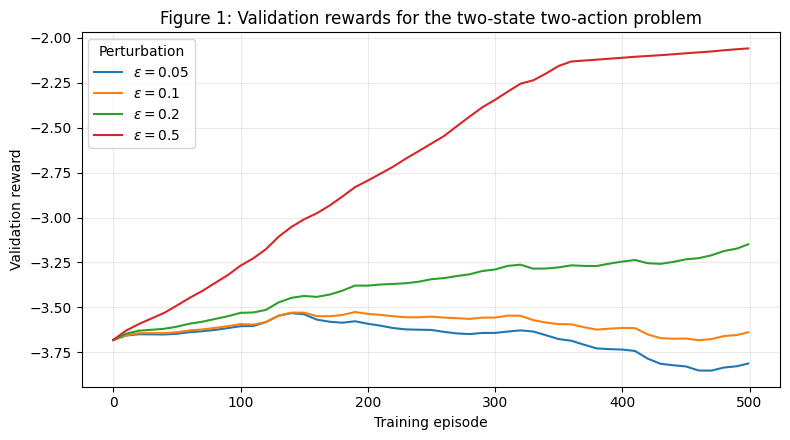

,avg_abs_err_pi(ST|0),std_abs_err_pi(ST|0),avg_abs_err_pi(ST|1),std_abs_err_pi(ST|1),avg_abs_err_policy
epsilon,,,,,
0.05,0.3038,NaN,0.2416,NaN,0.2727
0.10,0.2954,NaN,0.2527,NaN,0.2740
0.20,0.2712,NaN,0.2834,NaN,0.2773
0.50,0.1951,NaN,0.3874,NaN,0.2913


In [8]:
# Figure 1 and Table 1
import pandas as pd

if "experiment_one_results" not in globals():
    raise RuntimeError("Run the training cell above first so experiment_one_results contains the 5 runs per epsilon.")

fig, ax = plt.subplots(figsize=(8, 4.5))
table_rows = []

for eps in epsilon_range:
    runs = experiment_one_results[eps]
    if len(runs) != training_runs:
        raise ValueError(f"eps={eps} has {len(runs)} runs, expected {training_runs}.")

    episodes = np.asarray(runs[0]["history"]["episode"], dtype=float)
    validation_rewards = np.asarray(
        [run["history"]["validation_value"] for run in runs],
        dtype=float,
    )
    reward_mean = validation_rewards.mean(axis=0)
    reward_std = validation_rewards.std(axis=0, ddof=1)

    ax.plot(episodes, reward_mean, label=rf"$\varepsilon={eps}$")
    ax.fill_between(episodes, reward_mean - reward_std, reward_mean + reward_std, alpha=0.18)

    pi_star = runs[0]["optimal_policy"].detach().cpu().numpy()
    final_policies = np.asarray(
        [run["final_policy"].detach().cpu().numpy() for run in runs],
        dtype=float,
    )
    st_errors = np.abs(final_policies[:, :, 0] - pi_star[:, 0])

    table_rows.append(
        {
            "epsilon": eps,
            "avg_abs_err_pi(ST|0)": st_errors[:, 0].mean(),
            "std_abs_err_pi(ST|0)": st_errors[:, 0].std(ddof=1),
            "avg_abs_err_pi(ST|1)": st_errors[:, 1].mean(),
            "std_abs_err_pi(ST|1)": st_errors[:, 1].std(ddof=1),
            "avg_abs_err_policy": st_errors.mean(axis=1).mean(),
        }
    )

ax.set_title("Figure 1: Validation rewards for the two-state two-action problem")
ax.set_xlabel("Training episode")
ax.set_ylabel("Validation reward")
ax.legend(title="Perturbation")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

table_1 = pd.DataFrame(table_rows).set_index("epsilon")
display(table_1.round(4))

## 2. Cybersecurity Example [Meunier2026][25][6]
References:
[25] Vassili N Kolokoltsov and Alain Bensoussan. Mean-field-game model for botnet defense in cybersecurity. Applied Mathematics & Optimization, 74(3):669–692, 2016
[6] Ren´e Carmona, Mathieu Lauri`ere, and Zongjun Tan. Model-free mean-field reinforcement learning: mean-field MDP and mean-field Q-learning. The Annals of Applied Probability, 33(6B):5334–5381, 2023

We consider a large population of computers.

Four states:
- DI: defended and infected
- DS: defended and susceptible
- UI: undefended and infected
- US: undefended and susceptible

Action space is $\mathcal A = \{0,1\}$, where $0$ means keeping the same level of protection $\mathrm D$ or $\mathrm U$, and $1$ means updating the level of protection (from $\mathrm D$ to $\mathrm U$ or vice versa).

When infected, the computer recovers at rate $q_\mathrm{rec}^D$ or $q_\mathrm{rec}^U$ depending on the level of protection. When susceptible, the computer might
be infected either directly by a hacker or by the other infected computers, at rates depending on the level of protection of the susceptible computer and the other infected computers.

Originally the problem was formulated in continuous time, and the infinitesimal generator matrix can be written, given the current distribution of the population $\mu$ and action chosen by the computer $a$, as
\begin{align}
    Q^{\mu, a} =
    \begin{pmatrix}
        \dots & q_{\mathrm{rec}}^D & \lambda a & 0 \\
        Q_{\mathrm{DS} \rightarrow \mathrm{DI}}^{\mu, a} & \dots & 0 & \lambda a \\
        \lambda a & 0 & \dots & q_\mathrm{rec}^U \\
        0 & \lambda a & Q_{\mathrm{US} \rightarrow \mathrm{UI}} & \dots  
    \end{pmatrix},
\end{align}
where
\begin{align}
    Q_{\mathrm{DS} \rightarrow \mathrm{DI}}^{\mu, a} &= v_H q_\mathrm{inf}^D + \beta_{\mathrm{DD}}\mu(\mathrm{DI}) + \beta_{\mathrm{UD}}\mu(UI), \\
    Q_{\mathrm{US} \rightarrow \mathrm{UI}}^{\mu, a} &= v_H q_\mathrm{inf}^U + \beta_\mathrm{UU}\mu(\mathrm{UI}) + \beta_\mathrm{DU}\mu(\mathrm{DI}),
\end{align}
and all instances of $\dots$ should be replaced by values to make each row sum to $0$.

Each computer incurs a cost whenever it is defended or infected. The individual cost per unit of time is given by $f(x) = k_D\mathbf 1_{x\in\{\mathrm{DI}, \mathrm{DS}\}} + k_I\mathbf 1_{x\in\{\mathrm{DI},\mathrm{UI} \}}.

The model is adapted to a discrete time setting by considering a time grid $0, \Delta t, 2\Delta t, \ldots, N_{\mathrm{epi}}\Delta t$. Between two points of the time grid, the transition matrix is given by $P_{\Delta t}^{\mu, a} = \exp(\Delta t Q^{\mu, a})$, and the running reward is $r_{\Delta t}(x, a, \mu) = r_{\Delta t}(x) = -\Delta t f(x)$.

For the numerical experiments, we use the same values for the parameters as in [Meunier2026]. The rewards are discounted by $\gamma =0.5$ and the terminal reward is taken to be the same as the running reward.

The training and evaluation are done as follows. As the transition probability is stationary and the terminal reward is the same as the step reward, the length of a training episode is taken to be $T_\mathrm{train}=3$ to mitigate the "curse of time" (cf. [Meunier2026] - Remark 3.2), and for each training episode we simulate the population starting from a random initial distribution $\mu\in \mathcal P(\mathcal X)^\star$. Every 10 training episodes, we freeze the policy and sample a validation episode of length $T_\mathrm{val}=50$, for which we compute the population reward $V(\mu_0)$ starting from a fixed initial distribution $\mu_0=(1/4, 1/4, 1/4, 1/4).
During training, we compute $N=200$ trajectories for MF-REINFORCE, with $n=1$ trajectory for the gradient of the logits estimation. The policy is given by a 2-layer MLP, with 32 hidden units and tanh activations; it takes as input $t, \mu$ and outputs a $|\mathcal X|\times |\mathcal A|$ matrix corresponding to the probability of each action given each state.
We use the Adam optimzer and train for $20,000$ epochs using a learning of $10^{-3}$.
The experiments are run for $\varepsilon \in \{0.2, 0.5,1.0,2.0\}$.

FINDINGS: We clearly see the effect of $\varepsilon$ on the variance of the overall training algorithm: the smaller the perturbation, the more erratic the gradient estimation becomes, which leads to slower convergence. Surprisingly, taking a smaller
value of epsilon does not lead to a better policy. To confirm that the policy obtained is not suboptimal, we compare the state distribution evolution under the learned policy to the results obtained in [6] with mean-field Q-learning. The resulting flow of distributions is shown in Figure 3. Clearly, we see that the qualitative behaviour of the population under the policy learned using
MF-REINFORCE eventually matches the one learned using mean-field Q-learning in [6].

In [ ]:
# Parameters
beta_UU = 0.3
beta_UD = 0.4
beta_DU = 0.3
beta_DD = 0.4
q_rec_D = 0.5
q_rec_U = 0.4
q_inf_D = 0.4
q_inf_U = 0.3
v_H = 0.6
lam = 0.8
k_D = 0.3
k_I = 0.5
dt = 0.2

# Training
gamma = 0.5
T_train = 3
T_val = 50
mu0 = (0.25, 0.25, 0.25, 0.25)
N = 200 # trajectories for MF-REINFORCE
n = 1 # trajectoy for the gradient of the logits estimation
mlp_layers = 2
lr = 1e-3
n_train = 20_000
epsilon_range = [0.05, 0.1, 0.2, 0.5]

## 3. Distribution Planning Example